# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (simple seasonal average + trend):**
1. Compute average YoY growth rate from 2013–2022.
2. Build a "seasonal profile" — the average Revenue/COGS for each calendar day-of-year across all historical years.
3. Scale the profile by the projected year-level trend to produce predictions.

## 1 — Imports & Config

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import os

DATA_DIR    = '../data/raw/'
DATA_DIR_CLEAN = '../artifacts/cleaned_data/'
TRAIN_FILE  = DATA_DIR + 'analytical/sales.csv'
WEB_TRAFFIC = DATA_DIR_CLEAN + 'web_traffic.csv'
INVENTORY   = DATA_DIR_CLEAN + 'inventory.csv'
PROMOTIONS  = DATA_DIR_CLEAN + 'promotions.csv'
SUBMISSION_TMPL = DATA_DIR_CLEAN + 'sample_submission.csv'
OUT_FILE   = '../data/submissions/submission.csv'

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Imports & config successful!")

Imports & config successful!


## 2 — Load & Inspect Data

In [35]:
df = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
df  = df.sort_values('Date').reset_index(drop=True)

submission = pd.read_csv(SUBMISSION_TMPL, parse_dates=['Date'])

print(f"Train shape: {df.shape}")
print(f"Train date range: {df['Date'].min()} -> {df['Date'].max()}")
print()
print(df.head())
print(df.isnull().sum())
print(df.describe())

print(f"--- Submission Template ---")
print(f"Shape: {submission.shape}")
print(f"Submission date range: {submission['Date'].min()} -> {submission['Date'].max()}")
print(f"Head of submission template:")
print(submission.head())

Train shape: (3833, 3)
Train date range: 2012-07-04 00:00:00 -> 2022-12-31 00:00:00

        Date     Revenue        COGS
0 2012-07-04  5123547.94  3982991.19
1 2012-07-05  2751773.45  2150580.23
2 2012-07-06  3054029.42  2517632.84
3 2012-07-07  2667930.94  2108246.62
4 2012-07-08  2360851.90  1808622.79
Date       0
Revenue    0
COGS       0
dtype: int64
                      Date       Revenue          COGS
count                 3833  3.833000e+03  3.833000e+03
mean   2017-10-02 00:00:00  4.286584e+06  3.695134e+06
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06
max    2022-12-31 00:00:00  2.090527e+07  1.653586e+07
std                    NaN  2.624840e+06  2.219789e+06
--- Submission Template ---
Shape: (548, 3)
Submission date range: 2023-01-01 00:00:00 -> 2024-07-01 00:00:00
Head of submission template:
       

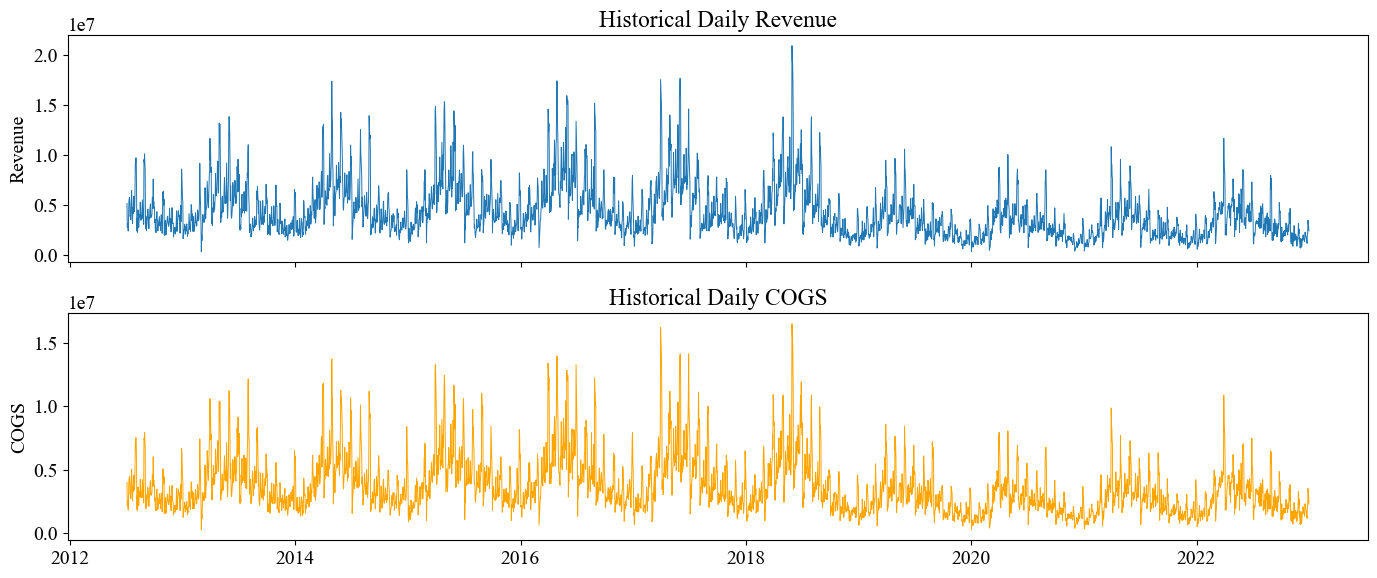

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df['Date'], df['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')

axes[1].plot(df['Date'], df['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3 — Feature Engineering

In [37]:
df_full = pd.concat([
    df[['Date', 'Revenue', 'COGS']],
    submission[['Date', 'Revenue', 'COGS']]
], ignore_index=True)

df_full = df_full.sort_values('Date').reset_index(drop=True)

print(f"Sum shape: {df_full.shape[0]}")
print(f"Date range: {df_full['Date'].min()} -> {df_full['Date'].max()}")

# -- Create Calendar features --
df_full['dayofweek']    = df_full['Date'].dt.dayofweek
df_full['month']        = df_full['Date'].dt.month
df_full['quarter']      = df_full['Date'].dt.quarter
df_full['dayofyear']    = df_full['Date'].dt.dayofyear
df_full['year']         = df_full['Date'].dt.year
df_full['weekofyear']   = df_full['Date'].dt.isocalendar().week.astype(int)
df_full['is_weekend']   = (df_full['dayofweek'] >= 5).astype(int)
df_full['is_month_end'] = df_full['Date'].dt.is_month_end.astype(int)
df_full['is_month_start'] = df_full['Date'].dt.is_month_start.astype(int)
df_full['is_quarter_end'] = df_full['Date'].dt.is_quarter_end.astype(int)   

# Trend tuyên tính
df_full['time_index']   = (df_full['Date'] - df_full['Date'].min()).dt.days

# -- Fourier features --
for k in range(1, 4):                                          
    df_full[f'sin_year_{k}'] = np.sin(2 * np.pi * k * df_full['dayofyear'] / 365.25)
    df_full[f'cos_year_{k}'] = np.cos(2 * np.pi * k * df_full['dayofyear'] / 365.25)

df_full['sin_week'] = np.sin(2 * np.pi * df_full['dayofweek'] / 7)
df_full['cos_week'] = np.cos(2 * np.pi * df_full['dayofweek'] / 7)

# -- Lag features --
for lag in [7, 14, 30, 60, 90, 365, 730]:
    df_full[f'rev_lag_{lag}'] = df_full['Revenue'].shift(lag)

# -- Rolling Statistics --
for window in [7, 14, 30, 60]:
    shifted = df_full['Revenue'].shift(1)
    df_full[f'rev_roll_mean_{window}'] = shifted.rolling(window, min_periods=1).mean()
    df_full[f'rev_roll_std_{window}'] = shifted.rolling(window, min_periods=1).std()

for window in [7, 14, 30]:
    df_full[f'rev_lag365_roll_{window}'] = (
        df_full['Revenue']
        .shift(365)
        .rolling(window, min_periods=1).mean()
        .fillna(df_full['Revenue'].rolling(30, min_periods=1).mean())
    )

print(f"Number of columns after Moving Average: {df_full.shape[1]}")

# -- Split TRAIN & TEST --
#cutoff = pd.Timestamp('2022-12-31')
train_fe = df_full[df_full['Date'] <= '2022-12-31'].copy()
test_fe = df_full[df_full['Date'] >= '2023-01-01'].copy()

print(f"Train after feature engineering: {train_fe.shape}")
print(f"Test after feature engineering: {test_fe.shape}")

Sum shape: 4381
Date range: 2012-07-04 00:00:00 -> 2024-07-01 00:00:00
Number of columns after Moving Average: 40
Train after feature engineering: (3833, 40)
Test after feature engineering: (548, 40)


In [38]:
# Load file promotions
promo = pd.read_csv(PROMOTIONS, parse_dates=['start_date', 'end_date'])
print(f"Number of promotional programs: {len(promo)}")
print(promo.head())

def get_promo_features(date, promo_df):
    mask   = (promo_df['start_date'] <= date) & (promo_df['end_date'] >= date)
    active = promo_df[mask]
    return pd.Series({
        'promo_count':    len(active),
        'max_discount':   active['discount_value'].max() if len(active) > 0 else 0,  
        'is_promo_day':   int(len(active) > 0),
    })

promo_agg = df_full['Date'].apply(lambda d: get_promo_features(d, promo))
df_full[['promo_count', 'max_discount', 'is_promo_day']] = promo_agg

cutoff   = pd.Timestamp('2022-12-31')
train_fe = df_full[df_full['Date'] <= cutoff].copy()
test_fe  = df_full[df_full['Date'] >  cutoff].copy()

print(f"Number of day with promotions: {df_full['is_promo_day'].sum()}")
print(f"Number of day without promotions: {(df_full['is_promo_day'] == 0).sum()}")

print(f'Train: {train_fe.shape}')
print(f'Test:  {test_fe.shape}')

Number of promotional programs: 50
     promo_id          promo_name  promo_type  discount_value start_date  \
0  PROMO-0001    Spring Sale 2013  percentage            12.0 2013-03-18   
1  PROMO-0002  Mid-Year Sale 2013  percentage            18.0 2013-06-23   
2  PROMO-0003    Fall Launch 2013  percentage            10.0 2013-08-30   
3  PROMO-0004  Year-End Sale 2013  percentage            20.0 2013-11-18   
4  PROMO-0005  Urban Blowout 2013       fixed            50.0 2013-07-30   

    end_date applicable_category promo_channel  stackable_flag  \
0 2013-04-17                 NaN         email               1   
1 2013-07-22                 NaN        online               0   
2 2013-10-02                 NaN         email               0   
3 2014-01-02                 NaN  all_channels               0   
4 2013-09-02          Streetwear        online               0   

   min_order_value  
0                0  
1                0  
2                0  
3            50000  
4     

## 4 — Train LightGBM Model

In [39]:
import xgboost as xgb

FEATURE_COLS = [col for col in train_fe.columns 
                if col not in ['Date', 'Revenue', 'COGS']]

print(f"Number of features: {len(FEATURE_COLS)}")

X_train = train_fe[FEATURE_COLS]
y_rev   = train_fe['Revenue']
y_cogs  = train_fe['COGS']

folds = [
    ('2019-12-31', '2020-01-01', '2020-12-31'),
    ('2020-12-31', '2021-01-01', '2021-12-31'),
    ('2021-12-31', '2022-01-01', '2022-12-31'),
]

print("\n--- Time-Series CV ---")
cv_scores = []

for train_end, val_start, val_end in folds:
    fold_train = train_fe[train_fe['Date'] <= train_end].copy()
    fold_val   = train_fe[(train_fe['Date'] >= val_start) & 
                          (train_fe['Date'] <= val_end)].copy()

    model_cv = lgb.LGBMRegressor(
        n_estimators        =2000,
        learning_rate       =0.01,
        max_depth           =8,
        num_leaves          =127,
        subsample           =0.7,
        colsample_bytree    =0.7,
        min_child_samples   =15,
        reg_alpha           =0.05,
        reg_lambda          =0.05,
        random_state        =RANDOM_SEED,
        verbose             =-1,
        n_jobs              =-1,
    )
    
    model_cv.fit(fold_train[FEATURE_COLS], fold_train['Revenue'])

    y_pred = np.maximum(model_cv.predict(fold_val[FEATURE_COLS]), 0)
    mae  = mean_absolute_error(fold_val['Revenue'], y_pred)
    rmse = mean_squared_error(fold_val['Revenue'], y_pred) ** 0.5
    r2   = r2_score(fold_val['Revenue'], y_pred)
    cv_scores.append({'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"  Validate {val_start[:4]}: MAE={mae:,.0f} | RMSE={rmse:,.0f} | R\u00b2={r2:.4f}")

avg_mae  = sum(s['MAE']  for s in cv_scores) / len(cv_scores)
avg_rmse = sum(s['RMSE'] for s in cv_scores) / len(cv_scores)
avg_r2   = sum(s['R2']   for s in cv_scores) / len(cv_scores)
print(f"\nAverage: MAE={avg_mae:,.0f} | RMSE={avg_rmse:,.0f} | R\u00b2={avg_r2:.4f}")

# -- Train on all data --
model_rev = lgb.LGBMRegressor(
    n_estimators        = 2000, 
    learning_rate       = 0.01,
    max_depth           = 8, 
    num_leaves          = 127,
    subsample           = 0.7,
    colsample_bytree    = 0.7,
    min_child_samples   = 15,
    reg_alpha           = 0.05,
    reg_lambda          = 0.05,
    random_state        = RANDOM_SEED, 
    verbose             =-1,
    n_jobs              =-1,
)
model_rev.fit(X_train, y_rev)

model_cogs = lgb.LGBMRegressor(
    n_estimators        = 2000, 
    learning_rate       = 0.01,
    max_depth           = 8, 
    num_leaves          = 127,
    subsample           = 0.7,
    colsample_bytree    = 0.7,
    min_child_samples   = 15,
    reg_alpha           = 0.05,
    reg_lambda          = 0.05,
    random_state        = RANDOM_SEED,
    verbose             =-1,
    n_jobs              =-1,
)
model_cogs.fit(X_train, y_cogs)

print("\nTrain successful!")

Number of features: 40

--- Time-Series CV ---
  Validate 2020: MAE=553,615 | RMSE=810,011 | R²=0.7546
  Validate 2021: MAE=575,536 | RMSE=805,093 | R²=0.7595
  Validate 2022: MAE=579,650 | RMSE=825,384 | R²=0.7568

Average: MAE=569,600 | RMSE=813,496 | R²=0.7570

Train successful!


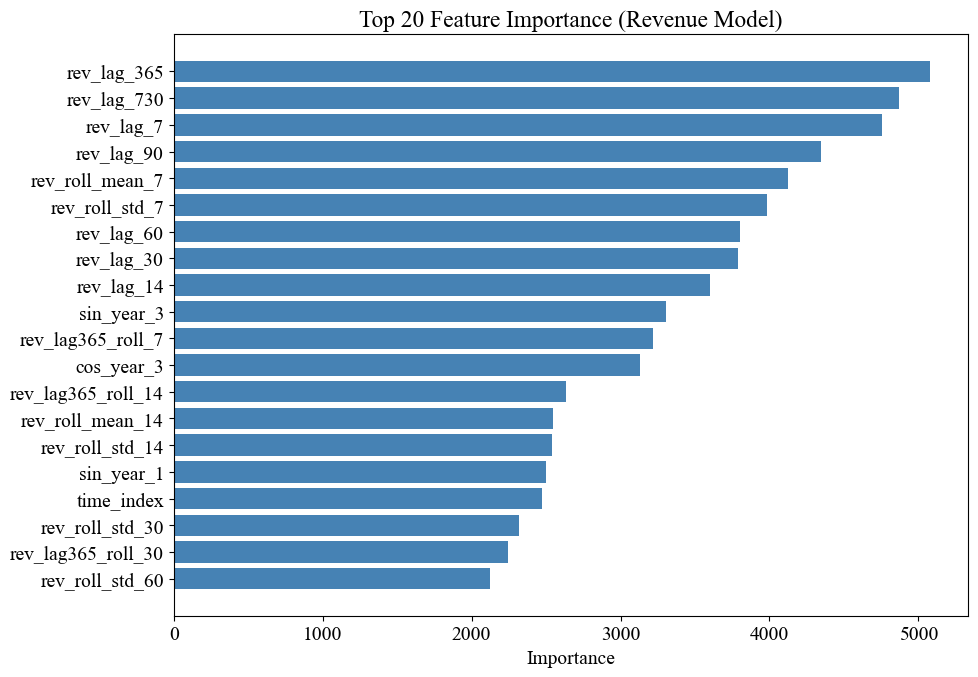

Top 10 features:
        feature  importance
    rev_lag_365        5079
    rev_lag_730        4870
      rev_lag_7        4755
     rev_lag_90        4346
rev_roll_mean_7        4126
 rev_roll_std_7        3982
     rev_lag_60        3804
     rev_lag_30        3788
     rev_lag_14        3603
     sin_year_3        3305


In [40]:
feat_imp = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': model_rev.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color='steelblue')
ax.set_title('Top 20 Feature Importance (Revenue Model)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).to_string(index=False))

## 5 — Predict & Export Submission

In [41]:
history = df_full.copy()

pred_dates = test_fe['Date'].sort_values().tolist()
pred_revs  = []
pred_cogs_list = []

print(f'Predicting {len(pred_dates)} days recursively...')

for i, date in enumerate(pred_dates):
    if i % 100 == 0:
        print(f'  Day {i+1}/{len(pred_dates)}: {date.date()}')

    row_idx = history[history['Date'] == date].index[0]

    # Tính lại lag features
    for lag in [7, 14, 30, 60, 90, 365, 730]:
        lag_date = date - pd.Timedelta(days=lag)
        lag_row  = history[history['Date'] == lag_date]
        if len(lag_row) > 0:
            history.loc[row_idx, f'rev_lag_{lag}'] = lag_row['Revenue'].values[0]

    # Tính lại rolling features
    past_rev = history[history['Date'] < date]['Revenue'].values
    for window in [7, 14, 30]:
        if len(past_rev) >= 1:
            history.loc[row_idx, f'rev_roll_mean_{window}'] = past_rev[-window:].mean()
            history.loc[row_idx, f'rev_roll_std_{window}']  = past_rev[-window:].std() if len(past_rev[-window:]) > 1 else 0

    # Tính lại YoY rolling features
    for window in [7, 14, 30]:
        lag365_start = date - pd.Timedelta(days=365+window//2)
        lag365_end   = date - pd.Timedelta(days=365-window//2)
        yoy_vals = history[(history['Date'] >= lag365_start) &
                           (history['Date'] <= lag365_end)]['Revenue'].values
        if len(yoy_vals) > 0:
            history.loc[row_idx, f'rev_lag365_roll_{window}'] = yoy_vals.mean()

    # Predict
    X_row    = history.loc[[row_idx], FEATURE_COLS]
    rev_pred = max(float(model_rev.predict(X_row)[0]),  0)
    cog_pred = max(float(model_cogs.predict(X_row)[0]), 0)

    # Cập nhật history 
    history.loc[row_idx, 'Revenue'] = rev_pred
    history.loc[row_idx, 'COGS']    = cog_pred

    pred_revs.append(rev_pred)
    pred_cogs_list.append(cog_pred)

# Submission
submission_out = submission[['Date']].copy()
submission_out['Revenue'] = pred_revs
submission_out['COGS']    = pred_cogs_list

print(f'\nShape: {submission_out.shape}')
print(f'Negative Revenue: {(submission_out["Revenue"] < 0).sum()}')
print(submission_out.head())

os.makedirs(os.path.dirname(OUT_FILE), exist_ok=True)
submission_out.to_csv(OUT_FILE, index=False, date_format='%Y-%m-%d')
print(f'\nSubmission saved to: {OUT_FILE}')

Predicting 548 days recursively...
  Day 1/548: 2023-01-01
  Day 101/548: 2023-04-11
  Day 201/548: 2023-07-20
  Day 301/548: 2023-10-28
  Day 401/548: 2024-02-05
  Day 501/548: 2024-05-15

Shape: (548, 3)
Negative Revenue: 0
        Date       Revenue          COGS
0 2023-01-01  2.343318e+06  2.306607e+06
1 2023-01-02  2.088215e+06  1.915658e+06
2 2023-01-03  1.522837e+06  1.036435e+06
3 2023-01-04  1.501715e+06  9.850312e+05
4 2023-01-05  1.306097e+06  9.804473e+05

Submission saved to: ../data/submissions/submission.csv


## 5 — SHAP FEATURE IMPORTANCE

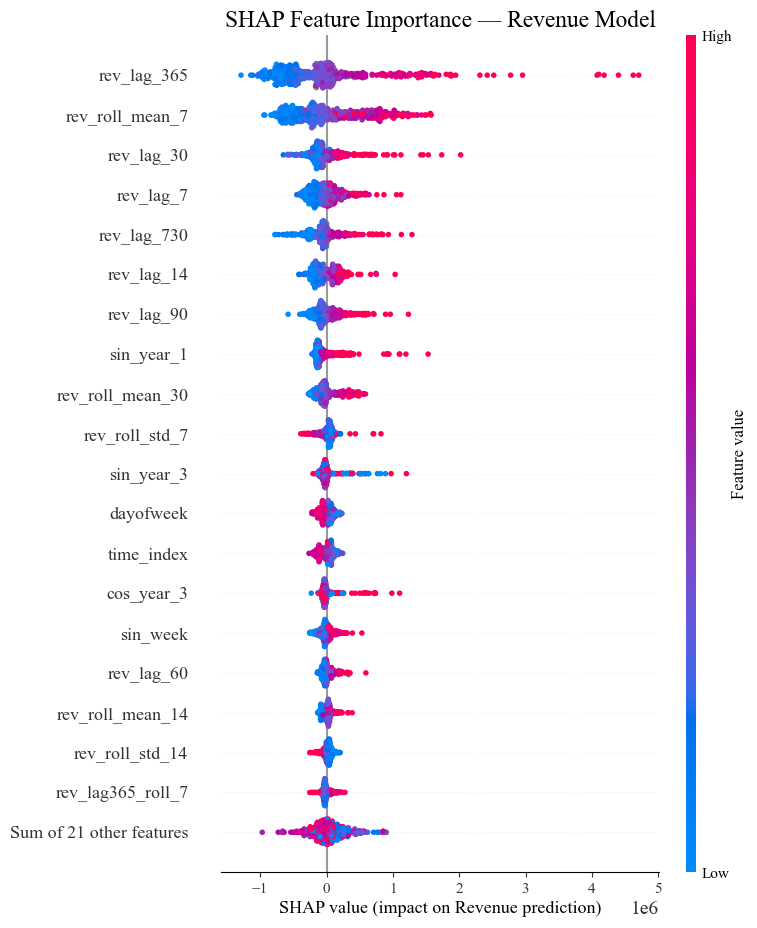

SHAP beeswarm plot saved!

Top 10 features:
         feature    importance
     rev_lag_365 575518.060820
 rev_roll_mean_7 456405.082614
      rev_lag_30 186681.796235
       rev_lag_7 169970.436465
     rev_lag_730 166727.200796
      rev_lag_14 153895.968999
      rev_lag_90 146356.773290
      sin_year_1 143784.634331
rev_roll_mean_30 139145.178294
  rev_roll_std_7  73765.207808

=== Giải thích bằng ngôn ngữ kinh doanh ===
  [575,518] rev_lag_365
         → Doanh thu cùng ngày năm ngoái — tín hiệu mùa vụ mạnh nhất

  [456,405] rev_roll_mean_7
         → Trung bình 7 ngày gần nhất — xu hướng tuần hiện tại

  [186,682] rev_lag_30
         → Doanh thu 30 ngày trước — chu kỳ mua sắm hàng tháng

  [169,970] rev_lag_7
         → Doanh thu 7 ngày trước — chu kỳ mua sắm hàng tuần

  [166,727] rev_lag_730
         → Doanh thu cùng ngày 2 năm trước — xu hướng dài hạn

  [153,896] rev_lag_14
         → rev_lag_14

  [146,357] rev_lag_90
         → Doanh thu 90 ngày trước — chu kỳ theo quý

  [

In [42]:
import shap
import matplotlib

matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size']   = 14

sample_idx  = np.random.choice(len(X_train), size=500, replace=False)
X_sample    = X_train.iloc[sample_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(model_rev)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

# Explanation object
explanation = shap.Explanation(
    values    = shap_values,
    base_values = explainer.expected_value,
    data      = X_sample.values,
    feature_names = FEATURE_COLS
)

plt.figure(figsize=(12, 9))
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title('SHAP Feature Importance — Revenue Model')
plt.xlabel('SHAP value (impact on Revenue prediction)')
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP beeswarm plot saved!')

# Top 10 + giải thích kinh doanh
shap_importance = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print('\nTop 10 features:')
print(shap_importance.head(10).to_string(index=False))

interpretations = {
    'rev_lag_365':       'Doanh thu cùng ngày năm ngoái — tín hiệu mùa vụ mạnh nhất',
    'rev_lag_730':       'Doanh thu cùng ngày 2 năm trước — xu hướng dài hạn',
    'rev_roll_mean_7':   'Trung bình 7 ngày gần nhất — xu hướng tuần hiện tại',
    'rev_roll_mean_30':  'Trung bình 30 ngày gần nhất — mức doanh thu nền',
    'rev_roll_mean_14':  'Trung bình 14 ngày gần nhất — xu hướng 2 tuần',
    'rev_roll_mean_60':  'Trung bình 60 ngày gần nhất — xu hướng 2 tháng',
    'rev_lag_7':         'Doanh thu 7 ngày trước — chu kỳ mua sắm hàng tuần',
    'rev_lag_30':        'Doanh thu 30 ngày trước — chu kỳ mua sắm hàng tháng',
    'rev_lag_90':        'Doanh thu 90 ngày trước — chu kỳ theo quý',
    'rev_lag365_roll_7': 'Trung bình 7 ngày cùng kỳ năm ngoái — làm mượt nhiễu',
    'time_index':        'Số ngày kể từ đầu — xu hướng tăng trưởng dài hạn',
    'sin_year_1':        'Fourier năm bậc 1 — mã hóa tính mùa vụ liên tục',
    'sin_year_3':        'Fourier năm bậc 3 — mã hóa tính mùa vụ bậc cao',
    'dayofweek':         'Ngày trong tuần — hành vi mua sắm khác nhau theo ngày',
    'is_promo_day':      'Cờ có khuyến mãi — giải thích đỉnh doanh thu đột biến',
}

print('\n=== Giải thích bằng ngôn ngữ kinh doanh ===')
for _, row in shap_importance.head(10).iterrows():
    interp = interpretations.get(row['feature'], row['feature'])
    print(f'  [{row["importance"]:,.0f}] {row["feature"]}')
    print(f'         → {interp}')
    print()